<a href="https://colab.research.google.com/github/Maryam-Shile/Intuitive_pythonista_projects/blob/main/yolov5_model_26_march_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 17851 (delta 34), reused 12 (delta 10), pack-reused 17801 (from 3)
Receiving objects: 100% (17851/17851), 16.98 MiB | 26.70 MiB/s, done.
Resolving deltas: 100% (12165/12165), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
!unzip -q '/content/My First Project.v6i.yolov5pytorch.zip' -d '/content/My First Project.v6i.yolov5pytorch'

In [ ]:
import os

base_path = "/content/food_data_2/food_data_2"
os.makedirs(f"/content/food_data_2/food_data_2/train/images", exist_ok=True)
os.makedirs(f"/content/food_data_2/food_data_2/train/labels", exist_ok=True)
os.makedirs(f"/content/food_data_2/food_data_2/validation/images", exist_ok=True)
os.makedirs(f"/content/food_data_2/food_data_2/validation/labels", exist_ok=True)
os.makedirs(f"/content/food_data_2/food_data_2/test/images", exist_ok=True)
os.makedirs(f"/content/food_data_2/food_data_2/test/labels", exist_ok=True)

In [ ]:
import glob
import shutil
import random

image_dir = f"/content/food_data_2/food_data_2/images"
label_dir = f"/content/food_data_2/food_data_2/labels"

image_paths = sorted(glob.glob(f"/content/food_data_2/food_data_2/images/*.jpg"))
random.seed(42)
random.shuffle(image_paths)

split_idx = int(0.8 * len(image_paths))
train_images = image_paths[:split_idx]
val_images = image_paths[split_idx:]

for img_path in train_images:
    img_name = os.path.basename(img_path)
    label_name = img_name.replace('.jpg', '.txt')

    shutil.move(img_path, f"/content/food_data_2/food_data_2/train/images/{img_name}")
    shutil.move(f"{label_dir}/{label_name}", f"/content/food_data_2/food_data_2/train/labels/{label_name}")

for img_path in val_images:
    img_name = os.path.basename(img_path)
    label_name = img_name.replace('.jpg', '.txt')

    shutil.move(img_path, f"/content/food_data_2/food_data_2/validation/images/{img_name}")
    shutil.move(f"{label_dir}/{label_name}", f"/content/food_data_2/food_data_2/validation/labels/{label_name}")


In [ ]:
!mv /content/food_data_2/food_data_2/validation/*.txt "/content/food_data_2/food_data_2/validation/labels"
!mv /content/food_data_2/food_data_2/validation/labels.cache "/content/food_data_2/food_data_2/validation/labels"

mv: cannot stat '/content/food_data_2/food_data_2/validation/*.txt': No such file or directory


In [ ]:
# @title Default title text
import yaml

data_yaml = {
    'train': f"/content/food_data_2/food_data_2/train/images",
    'val': f"/content/food_data_2/food_data_2/validation/images",
    'nc': 42,  # replace this
    'names': ['Boiled egg', 'Brocolli', 'Chicken', 'Egg sauce', 'Egusi pudding', 'Egusi soup', 'Fried Fish', 'Garri', 'Green spice sauce', 'Grilled Fish', 'Miyondo', 'Okra Soup', 'Onions', 'Pepper sauce', 'Pepper soup', 'Plum', 'Scrambled eggs', 'Seared Fish', 'Shrimp', 'Soup', 'Stew', 'Thripe', 'Vegetable', 'beans', 'beef', 'bobolo', 'boiled plantain', 'boiled yam', 'canda', 'dodo', 'egusi and okongobong', 'eru', 'fish', 'fufu', 'habanero pepper', 'ndole', 'omelette', 'palm oil', 'rice', 'smoked fish', 'stewed fish', 'unwrapped miyondo'] # replace this
}

with open(f"/content/food_data_2/food_data_2/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

!cat "/content/food_data_2/food_data_2/data.yaml"

FileNotFoundError: [Errno 2] No such file or directory: '/content/food_data_2/food_data_2/data.yaml'

In [ ]:
!mv '/content/data.yaml' '/content/My First Project.v6i.yolov5pytorch'

In [ ]:
!python train.py --img 640 --batch 20 --epochs 150 --data '/content/data.yaml' --weights yolov5s.pt --cache

Streaming output truncated to the last 5000 lines.
  with torch.cuda.amp.autocast(amp):
     98/149       5.4G    0.02079    0.03708     0.0074        187        640:  62% 28/45 [00:10<00:07,  2.36it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     98/149       5.4G    0.02077    0.03724   0.007396        285        640:  64% 29/45 [00:11<00:09,  1.76it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
     98/149       5.4G    0.02084    0.03735   0.007363        275        640:  67% 30/45 [00:11<00:07,  1.91it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):


In [ ]:
!python detect.py \
  --weights /content/yolov5/runs/train/exp2/weights/best.pt \
  --img 416 \
  --conf 0.25 \
  --source "/content/My First Project.v6i.yolov5pytorch/valid/images" ##/content/food_data_2/food_data_2/validation/images/

detect: weights=['/content/yolov5/runs/train/exp2/weights/best.pt'], source=/content/My First Project.v6i.yolov5pytorch/valid/images, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7144975 parameters, 0 gradients, 16.2 GFLOPs
image 1/190 /content/My First Project.v6i.yolov5pytorch/valid/images/Picture_42560_jpg.rf.e9aa896d320c84d45ccc02fc3dfa5aa4.jpg: 416x416 5 dodos, 6.1ms
image 2/190 /content/My First Project.v6i.yolov5pytorch/valid/images/Picture_44178_jpg.rf.73f9c213746e9fc908

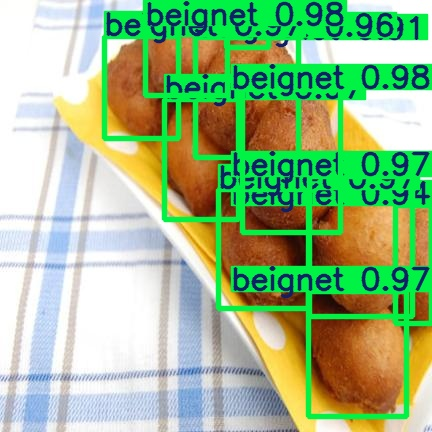

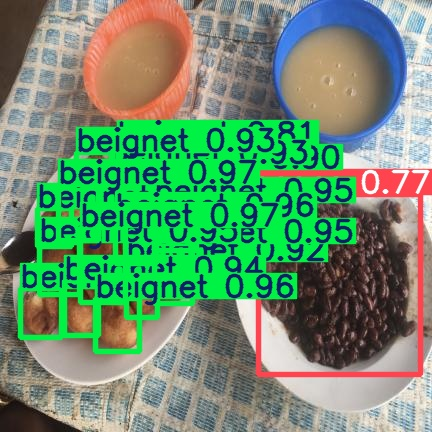

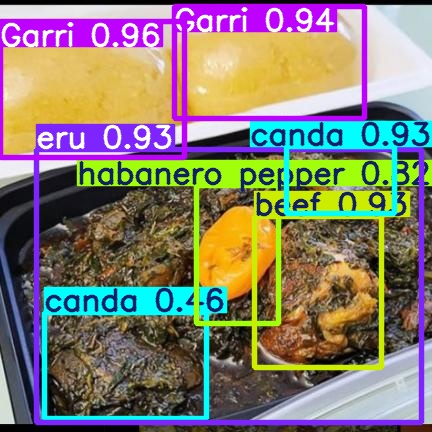

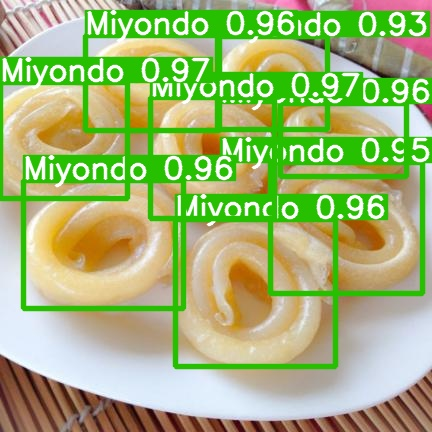

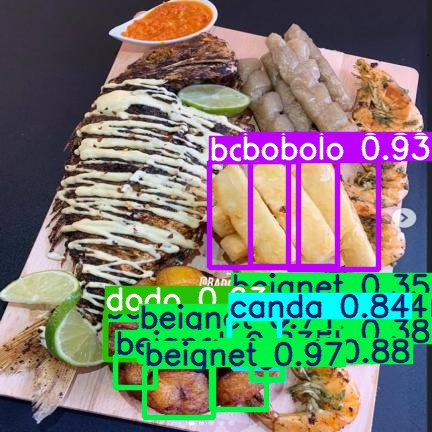

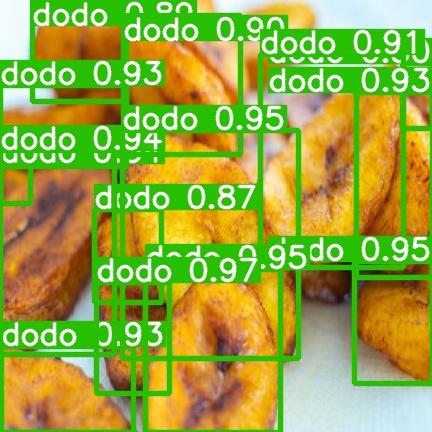

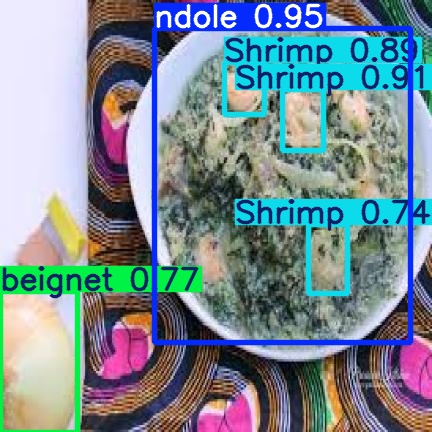

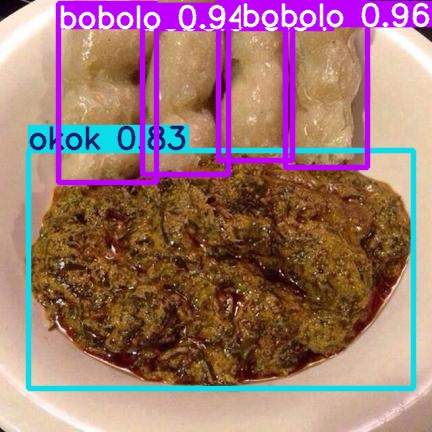

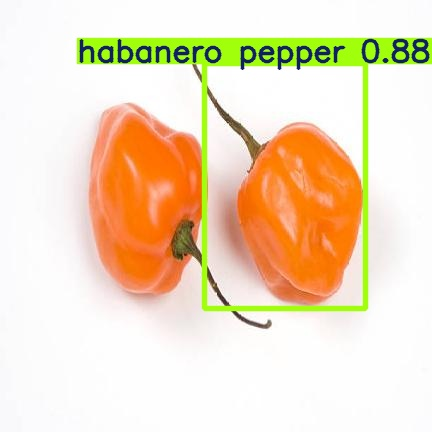

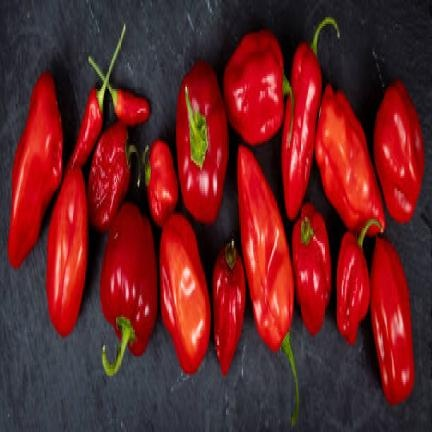

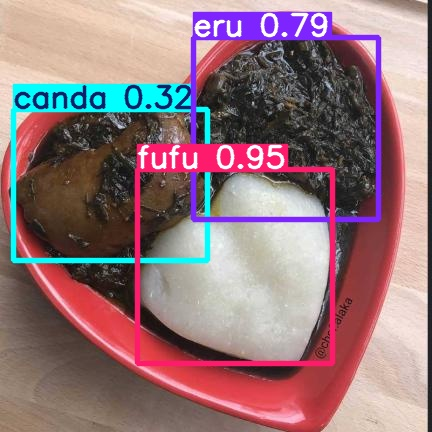

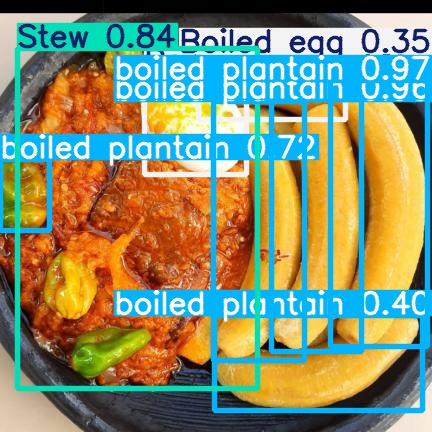

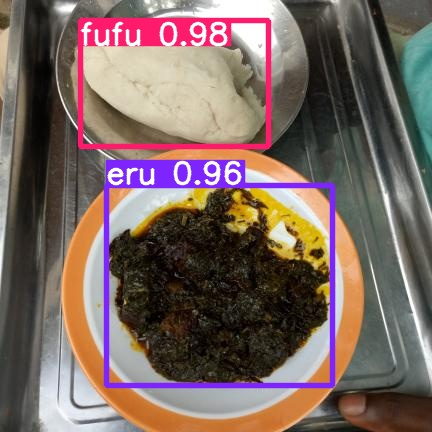

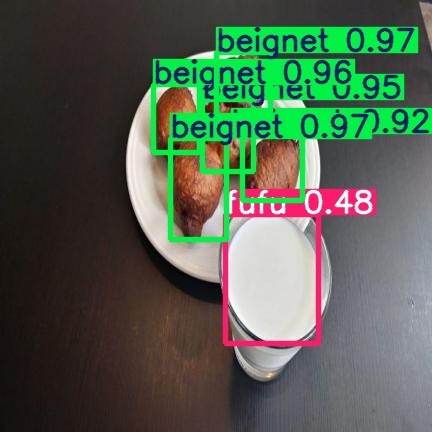

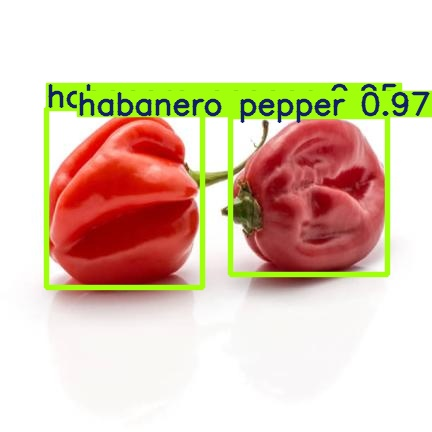

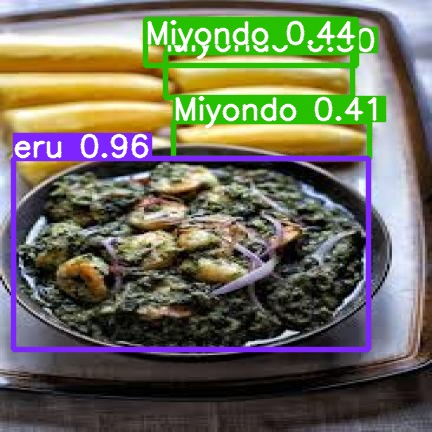

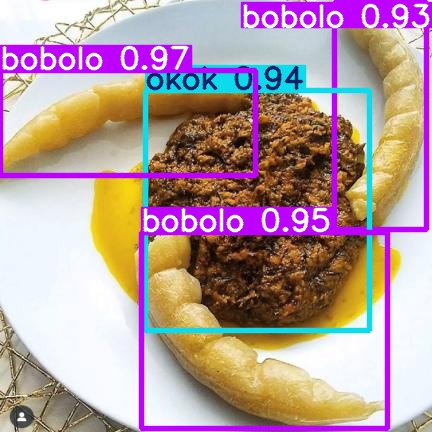

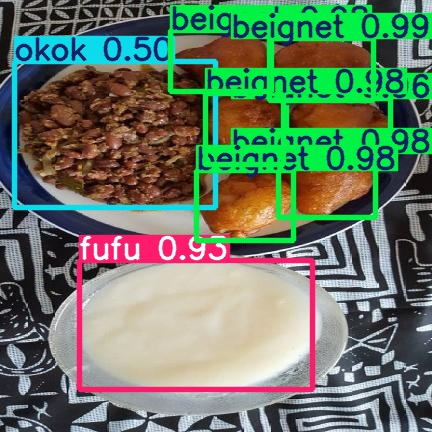

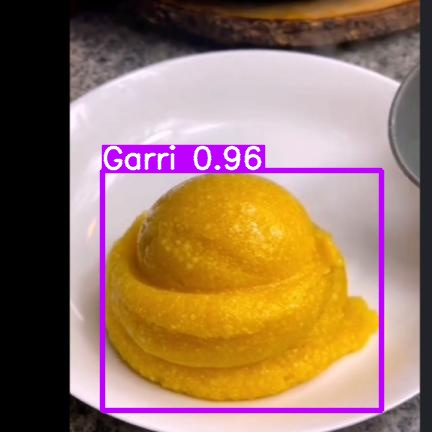

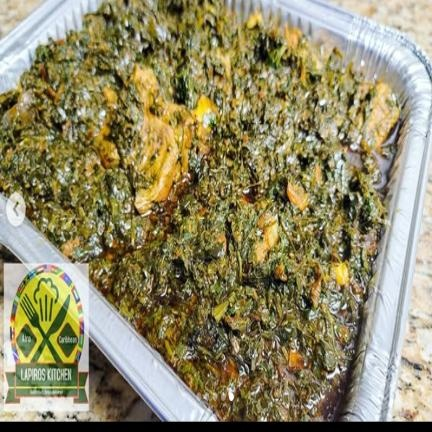

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/yolov5/runs/detect/exp2/*.jpg')[:20]:
    display(Image(filename=image_path, height=300))

In [ ]:
!zip -r /content/yolov5_training_backup.zip /content/yolov5
!zip -r /content/food_data_2.zip /content/food_data_2

  adding: content/yolov5/ (stored 0%)
  adding: content/yolov5/pyproject.toml (deflated 59%)
  adding: content/yolov5/.dockerignore (deflated 56%)
  adding: content/yolov5/.git/ (stored 0%)
  adding: content/yolov5/.git/config (deflated 33%)
  adding: content/yolov5/.git/HEAD (stored 0%)
  adding: content/yolov5/.git/packed-refs (deflated 48%)
  adding: content/yolov5/.git/info/ (stored 0%)
  adding: content/yolov5/.git/info/exclude (deflated 28%)
  adding: content/yolov5/.git/logs/ (stored 0%)
  adding: content/yolov5/.git/logs/HEAD (deflated 28%)
  adding: content/yolov5/.git/logs/refs/ (stored 0%)
  adding: content/yolov5/.git/logs/refs/remotes/ (stored 0%)
  adding: content/yolov5/.git/logs/refs/remotes/origin/ (stored 0%)
  adding: content/yolov5/.git/logs/refs/remotes/origin/HEAD (deflated 28%)
  adding: content/yolov5/.git/logs/refs/heads/ (stored 0%)
  adding: content/yolov5/.git/logs/refs/heads/master (deflated 28%)
  adding: content/yolov5/.git/refs/ (stored 0%)
  adding: con